# Exploratory Study of Gentle Quantum Leakage with Custom POVMs

This notebook documents an **exploratory stage** of my Master's Thesis research on information leakage in quantum communication. The objective is to study how much information can be extracted from the BB84 signal ensemble using several parameterized POVM families while explicitly tracking the disturbance introduced by the corresponding measurement implementation.

The analysis focuses on **weakly gentle measurements** with zero failure probability, using the trace distance as the disturbance metric and Sibson mutual information of order $\infty$ as the leakage metric.

> **Research context.** The results in this notebook were part of the investigation that preceded the final thesis methodology. They were not included in the final manuscript. Their role was to test concrete measurement constructions, understand the leakage--disturbance trade-off numerically, and identify the limitations of optimizing over hand-designed POVM families before moving to the cloning-region formulation used in the final study.


## Notebook roadmap

The notebook proceeds in four stages:

1. Define the gentleness condition and the leakage metric used throughout the study.
2. Implement the disturbance and leakage calculations for a fixed Kraus realization.
3. Explore three parameterized POVM constructions, including ideal and depolarizing-channel cases where applicable.
4. Compare the empirical leakage envelopes against the analytical lower bound obtained in the previous notebook.

The aim is not to claim global optimality over all POVMs, but to determine how far simple measurement families can approach the theoretical leakage--disturbance frontier.


In [1]:
import numpy as np
from scipy.linalg import sqrtm
import matplotlib.pyplot as plt
import cvxpy as cp
import math

(CVXPY) Sep 30 07:18:17 PM: Encountered unexpected exception importing solver GLOP:
RuntimeError('Unrecognized new version of ortools (9.15.6755). Expected < 9.15.0. Please open a feature request on cvxpy to enable support for this version.')
(CVXPY) Sep 30 07:18:17 PM: Encountered unexpected exception importing solver PDLP:
RuntimeError('Unrecognized new version of ortools (9.15.6755). Expected < 9.15.0. Please open a feature request on cvxpy to enable support for this version.')


## 1. Gentle-measurement framework


A measurement is considered *gentle* when the information extracted from the system is obtained without excessively modifying the input state. In this study, disturbance is quantified through the trace distance and controlled by two parameters: the disturbance threshold $\alpha$ and the allowed failure probability $\delta$.


### Weak gentleness

A POVM $\mathcal{F}=\{F_y\}_{y\in\mathcal{Y}}$ is $(\alpha,\delta)$-weakly gentle on an ensemble
$S=\{\rho^x\}_{x\in\mathcal{X}}$ if there exists at least one implementation
$\mathcal{B}=\{B_y\}_{y\in\mathcal{Y}}$, with $F_y=B_y^\dagger B_y$, for which the post-measurement disturbance remains below $\alpha$ with probability at least $1-\delta$:

$$
\mathbb{P}\!\left(
\left\|
\frac{B_y\rho^x B_y^\dagger}{\operatorname{tr}(\rho^xF_y)}
-\rho^x
\right\|_{\mathrm{tr}}
<\alpha,\ \forall x\in\mathcal{X}
\right)\ge 1-\delta.
$$

The relevant point for this notebook is the **existence** of a sufficiently gentle Kraus realization of the POVM.


### Strong gentleness

The strong notion requires the same gentleness condition to hold for **every** Kraus realization of the POVM. It is therefore strictly more restrictive than the weak definition:

$$
\forall \mathcal{B}:\quad
\mathbb{P}\!\left(
\left\|
\frac{B_y\rho^x B_y^\dagger}{\operatorname{tr}(\rho^xF_y)}
-\rho^x
\right\|_{\mathrm{tr}}
<\alpha,\ \forall x\in\mathcal{X}
\right)\ge 1-\delta.
$$

The numerical study below does not attempt to characterize strong gentleness; it evaluates specific implementations of candidate POVMs.


## 2. Reference lower bound


The previous notebook implemented the lower bound used as a reference throughout this study. For all $\alpha,\delta\in[0,1]$,

$$
\mathcal{L}_{(\alpha,\delta)}(X\!\rightarrow\!A)_\rho
\ge
\mathcal{L}_{(\alpha,0)}(X\!\rightarrow\!A)_\rho
\ge
\underline{\mathcal{L}}_\alpha(\{p^x\}_{x\in\mathcal{X}}).
$$

The lower bound is written as

$$
\underline{\mathcal{L}}_\alpha
=
\log_2\!\left(
p_2^*+(1-p_2^*)\,2^{Q(X\rightarrow A)_\rho}
\right),
$$

where $(p_1^*,p_2^*)$ is obtained from the constrained optimization associated with the cloning region. For the qubit case used here, the corresponding numerical solver is reused later to generate the comparison curve.

This bound provides a useful benchmark: the custom POVMs below are concrete constructions, whereas the analytical curve is derived independently of these particular measurement families.


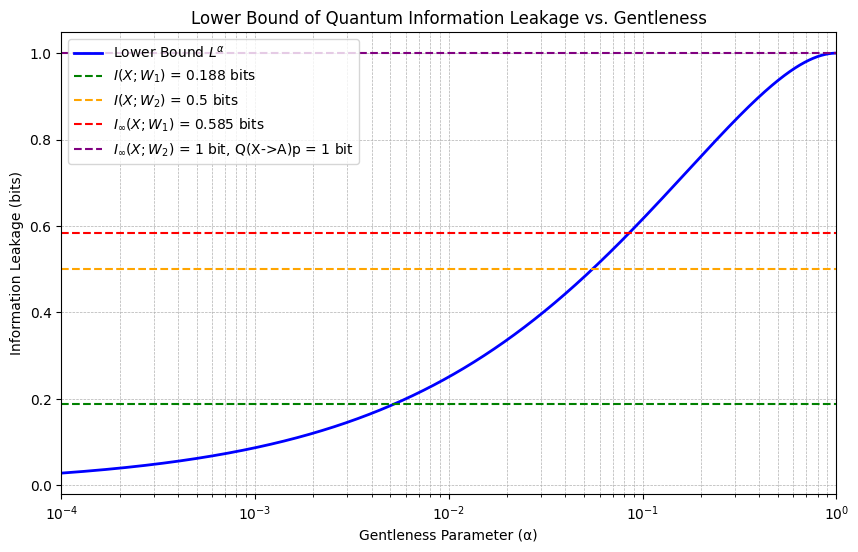

## 3. Working regime: weak gentleness with $\delta=0$


I restrict the exploratory analysis to the zero-failure-probability case, $\delta=0$. This turns the disturbance constraint into a deterministic worst-case requirement over the BB84 ensemble and all measurement outcomes considered by the chosen implementation.


### Disturbance criterion


For a fixed Kraus realization $\mathcal{B}=\{B_y\}$, the disturbance associated with an input $\rho^x$ and outcome $y$ is

$$
D_{\mathrm{tr}}\!\left(
\frac{B_y\rho^xB_y^\dagger}{\operatorname{tr}(\rho^xF_y)},
\rho^x
\right).
$$

The implementation-level gentleness parameter evaluated numerically in this notebook is therefore

$$
\alpha(\mathcal{B})
=
\max_{x,y}
D_{\mathrm{tr}}\!\left(
\frac{B_y\rho^xB_y^\dagger}{\operatorname{tr}(\rho^xF_y)},
\rho^x
\right),
$$

excluding outcomes with zero probability.


### Scope of the weak-gentleness search


Weak gentleness formally allows an optimization over all Kraus realizations of a given POVM. That full optimization is **not** carried out here. Instead, each parameterized family is assigned a specific Kraus realization, and the resulting pair

$$
\bigl(\alpha(\mathcal{B}),\, I_\infty(X;Y)\bigr)
$$

is recorded.

The numerical sweep then constructs an empirical upper envelope by retaining, for each $\alpha$ region, the largest leakage produced by the tested family. This makes the notebook a study of **explicit candidate attacks**, not a proof of the optimal gentle leakage.


In [2]:
POSSIBLE_STATES = [np.array([[1,0],[0,0]]),     # |0>
                np.array([[0,0],[0,1]]),        # |1>
                0.5*np.array([[1,1],[1,1]]),    # |+>
                0.5*np.array([[1,-1],[-1,1]])]  # |->

In [3]:
def trace_from_eigenvalues(A, clip=True, tol=1e-12):
    """
    Computes Tr(A) using eigenvalues.
    
    Parameters
    ----------
    A : np.ndarray
        Square matrix (assumed Hermitian).
    clip : bool
        If True, clips small negative eigenvalues caused by numerical noise.
    tol : float
        Tolerance for clipping.
    
    Returns
    -------
    float
        Trace of A computed as sum of eigenvalues.
    """
    # Enforce Hermiticity numerically
    A = (A + A.conj().T) / 2.0

    # Eigenvalues of Hermitian matrix
    eigvals = np.linalg.eigvalsh(A)

    if clip:
        eigvals = np.where(eigvals < tol, 0.0, eigvals)

    return float(np.sum(eigvals))

For an input state $\rho$ and a Kraus operator $B_y$, the normalized post-measurement state is

$$
\rho_{B|y}
=
\frac{B_y\rho B_y^\dagger}
{\operatorname{tr}(B_y\rho B_y^\dagger)}
=
\frac{B_y\rho B_y^\dagger}
{\operatorname{tr}(\rho F_y)}.
$$

This state is used directly in the disturbance calculation.


In [4]:
def calculate_post_measurement_state(rho, krauss_operator):
    """Given a density matrix rho and a krauss operator, calculates the post-measurement state (P_Y)"""
    numerator = krauss_operator @ rho @ krauss_operator.conj().T # Unnormalized post-measurement state
    denominator = np.trace(numerator) # Probability of obtaining the measurement outcome associated with the krauss operator
    if denominator == 0:
        return None  # Measurement outcome is impossible for this state
    return numerator / denominator # Normalized post-measurement state

The normalized trace distance between two quantum states $\rho$ and $\sigma$ is

$$
D_{\mathrm{tr}}(\rho,\sigma)
=
\frac{1}{2}\operatorname{tr}|\rho-\sigma|.
$$

For qubits, it can be evaluated efficiently from the eigenvalues of the Hermitian difference $\rho-\sigma$.


In [5]:
def hermitize(A):
    return 0.5*(A + A.conj().T)

def calculate_trace_distance(rho1, rho2):
    diff = hermitize(rho1 - rho2)
    eigvals = np.linalg.eigvalsh(diff)
    return 0.5 * np.sum(np.abs(eigvals))


The function below evaluates the worst-case trace distance over the BB84 signal states and over all outcomes of the selected Kraus realization. This quantity is the $\alpha$ coordinate assigned to each tested measurement.

Importantly, this is **not** a minimization over all possible implementations of the same POVM; that broader optimization is outside the scope of this exploratory notebook.


In [6]:
def calculate_alpha(krauss_operators, possible_states):
    """Calculates the gentleness parameter alpha for a given set of krauss operators and possible states"""
    
    max_trace_distance = 0
    
    for rho in possible_states:
        for  B in krauss_operators:
            
            post_measurement_state = calculate_post_measurement_state(rho, B)
            
            if post_measurement_state is not None:
                #Alpha calculation
                trace_distance = calculate_trace_distance(rho, post_measurement_state)
                max_trace_distance = max(max_trace_distance, trace_distance)
                
    return  float(np.real(max_trace_distance)) 

### Leakage metric

For a fixed POVM, the information leakage is quantified using Sibson mutual information of order $\infty$. The gentle quantum leakage is defined through a supremum over the admissible gentle POVMs,

$$
\mathcal{L}_{(\alpha,\delta)}(X\rightarrow A)_\rho
=
\sup_{\{F_y\}_y\in\mathcal{G}_{(\alpha,\delta)}}
I_\infty(X;Y).
$$

Enumerating all admissible POVMs is not tractable directly. The strategy here is therefore to choose several structured families, scan their free parameters, and compare the resulting leakage--disturbance points.


For a fixed POVM $\mathcal{F}=\{F_y\}$, the order-$\infty$ Sibson mutual information used in the implementation is

$$
I_\infty(X;Y)
=
\log_2\!\left(
\sum_{y\in\mathcal{Y}}
\max_{x\in\mathcal{X}}
\operatorname{tr}(\rho^xF_y)
\right).
$$

This expression depends only on the POVM effects $F_y=B_y^\dagger B_y$, whereas the disturbance also depends on the chosen Kraus realization.


In [7]:
def calculate_mutual_info_sibson(krauss_operators, possible_states):
    """Calculates the Sibson's mutual information I_infty(X;Y) 
    for a given set of krauss operators and possible states"""

    sum_max_traces = 0
    
    for B in krauss_operators:
        
        max_trace = 0
        
        for rho in possible_states:
            
            trace = np.trace(rho @ (B.conj().T @ B))
            max_trace = max(max_trace, trace)
            
        sum_max_traces += max_trace
    info = np.log2(sum_max_traces)
    
    return float(np.real(info))

## 4. Extension to a depolarizing channel


After studying the ideal BB84 ensemble, I repeat part of the analysis after applying a single-qubit depolarizing channel,

$$
\mathcal{E}_p(\rho)
=
(1-p)\rho
+\frac{p}{3}
\left(
X\rho X+Y\rho Y+Z\rho Z
\right),
\qquad p\in[0,1].
$$

This provides a simple way to test how reduced state distinguishability changes both the information available to the measurement and the associated disturbance.


In [8]:
def depolarising_channel(rho: np.ndarray, p: float) -> np.ndarray:
    """
    Apply a single-qubit depolarising channel to a density matrix.
    """

    if rho.shape != (2, 2):
        raise ValueError("Input state must be a 2x2 density matrix.")

    if not (0.0 <= p <= 1.0):
        raise ValueError("Depolarising probability p must be in [0, 1].")

    # Pauli matrices
    I = np.array([[1, 0],
                [0, 1]], dtype=complex)

    X = np.array([[0, 1],
                [1, 0]], dtype=complex)

    Y = np.array([[0, -1j],
                [1j, 0]], dtype=complex)

    Z = np.array([[1, 0],
                [0, -1]], dtype=complex)

    return (
        (1 - p) * rho
        + (p / 3) * (X @ rho @ X + Y @ rho @ Y + Z @ rho @ Z)
    )


## 5. Numerical exploration of custom POVMs


Each candidate family is parameterized by a small number of variables. For every parameter combination I:

1. construct the corresponding measurement operators,
2. evaluate the worst-case disturbance $\alpha$,
3. compute $I_\infty(X;Y)$,
4. bin the points in $\alpha$, and
5. retain the largest leakage in each bin to obtain an empirical upper envelope.

The resulting curves should be read as the best behavior found **within the sampled family and grid**, not as a global optimum.


### 5.1 POVM family 1: rotated rank-one perturbation


The first family is a binary POVM centered around $\tfrac{1}{2}I$ and perturbed along a pure-state direction

$$
|\psi(\theta)\rangle
=
\cos\theta\,|0\rangle+\sin\theta\,|1\rangle.
$$

The effects are

$$
F_0
=
\frac{1}{2}
\left(
I+\epsilon|\psi(\theta)\rangle\langle\psi(\theta)|
\right),
\qquad
F_1
=
\frac{1}{2}
\left(
I-\epsilon|\psi(\theta)\rangle\langle\psi(\theta)|
\right),
$$

with

$$
\epsilon\in[0,1],
\qquad
\theta\in\left[0,\frac{\pi}{4}\right].
$$

The principal square roots of the effects are used as the Kraus operators.


In [9]:
def generate_krauss_operators_set_1(epsilon, theta):
    """Given parameters epsilon and theta generates a set of POVMs
    and returns its krauss operators"""
    
    Id = np.array([[1,0],[0,1]])
    appendix = np.array([[np.cos(theta)*np.cos(theta), np.cos(theta)*np.sin(theta)],
                    [np.sin(theta)*np.cos(theta), np.sin(theta)*np.sin(theta)]])
    
    povm_0 = 0.5 * (Id + epsilon * appendix)
    povm_1 = 0.5 * (Id - epsilon * appendix)
    
    b0 = sqrtm(povm_0)
    b1 = sqrtm(povm_1)
    
    return b0,b1
    


Before performing the sweep, I verify the completeness relation

$$
B_0^\dagger B_0+B_1^\dagger B_1=I.
$$

The check must use matrix multiplication rather than element-wise multiplication.


In [10]:
b0, b1 = generate_krauss_operators_set_1(0.1, np.pi / 4)

print(f"{b0 = }")
print(f"{b1 = }")

Id_check = b0.conj().T @ b0 + b1.conj().T @ b1

print(f"Completeness check B0†B0 + B1†B1:\n{Id_check}")
print(f"Matches identity: {np.allclose(Id_check, np.eye(2), atol=1e-10)}")


b0 = array([[0.72436331, 0.01725653],
       [0.01725653, 0.72436331]])
b1 = array([[ 0.68896359, -0.01814319],
       [-0.01814319,  0.68896359]])
Completeness check B0†B0 + B1†B1:
[[ 1.00000000e+00 -1.07552856e-16]
 [-1.07552856e-16  1.00000000e+00]]
Matches identity: True


The parameter grid is now scanned over $(\epsilon,\theta)$. Each point produces one disturbance--leakage pair for the chosen Kraus implementation.


To make the trade-off easier to interpret, I divide the $\alpha$ axis into logarithmic bins and retain only the largest leakage found in each bin. This produces an empirical upper envelope of the sampled family.


In [11]:
n_alpha_bins = 1000
alpha_min, alpha_max = 1e-5, 1.0

alpha_bin_edges = np.logspace(
    np.log10(alpha_min),
    np.log10(alpha_max),
    n_alpha_bins + 1
)


def alpha_to_bin(alpha, bin_edges):
    idx = np.searchsorted(bin_edges, alpha, side="right") - 1
    if idx < 0 or idx >= len(bin_edges) - 1:
        return None
    return idx



In [12]:
# To store the upper curve
upper_envelope = {}

# Create linspace arrays for epsilon and theta
epsilon_values = np.linspace(0, 1, 250)
theta_values = np.linspace(0, np.pi/4, 250)

alpha_leakage_list_set_1 = []
# Scan all sampled (epsilon, theta) combinations
for epsilon in epsilon_values:
    for theta in theta_values:
        
        # Generate Kraus operators for the current parameters
        b0, b1 = generate_krauss_operators_set_1(epsilon, theta)
        krauss_operators = [b0, b1]
        
        # Calculate alpha and leakage
        alpha = calculate_alpha(krauss_operators, POSSIBLE_STATES)
        leakage = calculate_mutual_info_sibson(krauss_operators, POSSIBLE_STATES)
        
        # Store results
        alpha_leakage_list_set_1.append((alpha, leakage))
        
        bin_idx = alpha_to_bin(alpha, alpha_bin_edges)
        if bin_idx is None:
            continue

        # Keep only the maximum leakage per alpha-bin
        if bin_idx not in upper_envelope:
            upper_envelope[bin_idx] = {
                "alpha": alpha,
                "leakage": leakage,
                "params": (epsilon, theta),
            }
        else:
            if leakage > upper_envelope[bin_idx]["leakage"]:
                upper_envelope[bin_idx] = {
                    "alpha": alpha,
                    "leakage": leakage,
                    "params": (epsilon, theta),
                }


C:\Users\pablo\AppData\Local\Temp\ipykernel_10340\3768467288.py:13: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  b1 = sqrtm(povm_1)


The complete cloud of sampled points is first sorted by $\alpha$ and plotted directly. This shows how much redundancy exists in the parameterization before taking the envelope.


In [13]:
# Sort alpha_leakage_list by alpha (first element of each tuple)
alpha_leakage_list_set_1_sorted = sorted(alpha_leakage_list_set_1, key=lambda x: x[0])

# Extract alpha and leakage values
alphas_set_1 = [item[0] for item in alpha_leakage_list_set_1_sorted]
leakages_set_1 = [item[1] for item in alpha_leakage_list_set_1_sorted]

A logarithmic $\alpha$ axis is useful because the low-disturbance regime is the most relevant region when studying attacks that are intended to remain difficult to detect.


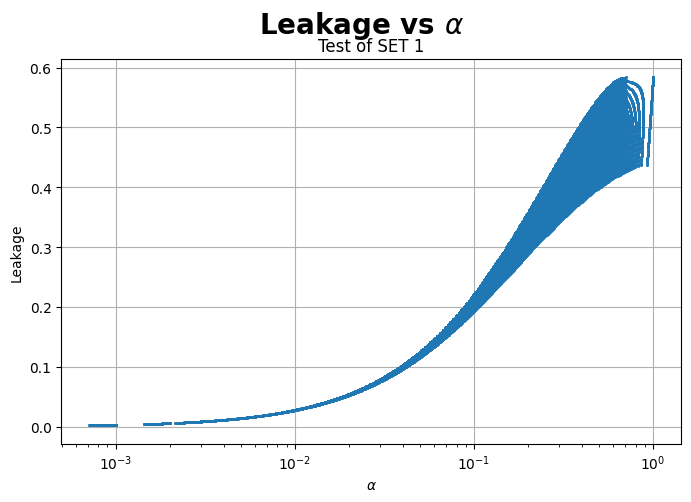

In [14]:
# Plot with logarithmic x-axis
plt.figure(figsize=(8, 5))
plt.plot(alphas_set_1, leakages_set_1, marker='.', linestyle='None', markersize=2)
plt.xlabel(r'$\alpha$')
plt.ylabel('Leakage')
plt.title(r'Test of SET 1', fontsize=12)
plt.suptitle(r'Leakage vs $\alpha$', fontsize=20, fontweight='bold')  # Bigger main title
plt.xscale('log')  # Set x-axis to logarithmic scale
plt.grid(True)
plt.show()

The upper envelope below summarizes the best leakage found in each disturbance bin for POVM family 1.


In [15]:
alpha_upper = []
leakage_upper = []

for idx in sorted(upper_envelope.keys()):
    alpha_upper.append(upper_envelope[idx]["alpha"])
    leakage_upper.append(upper_envelope[idx]["leakage"])


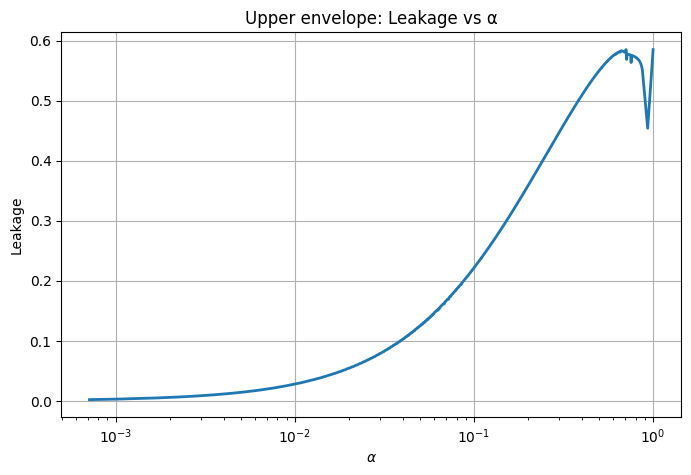

In [16]:
plt.figure(figsize=(8,5))
plt.plot(alpha_upper, leakage_upper, linewidth=2)
plt.xscale("log")
plt.xlabel(r"$\alpha$")
plt.ylabel("Leakage")
plt.title("Upper envelope: Leakage vs α")
plt.grid(True)
plt.show()


The empirical envelope can now be compared with the analytical lower bound from Notebook 1. A gap between the two curves indicates that this particular POVM family does not reproduce the behavior guaranteed by the more general construction underlying the bound.


In [17]:
def solve_lower_bound_p2(alpha_value):
    import cvxpy as cp
    p1 = cp.Variable()
    p2 = cp.Variable()
    constraints = [
        p1 >= 0, p1 <= 1,
        p2 >= 0, p2 <= 1,
        p1 <= alpha_value,
        3*(p1 - p2)**2 - 6*p1 - 6*p2 + 3 <= 0
    ]
    prob = cp.Problem(cp.Minimize(p2), constraints)
    prob.solve()
    return p2.value

def calculate_lower_bound_leakage(p2_star):
    Q = 1
    argument = p2_star + (1 - p2_star) * (2**Q)
    if argument > 0:
        return math.log2(argument)
    else:
        return -float('inf')

In [18]:
# --- Prepare lower bound data ---
alpha_values_lb = np.logspace(-4, 0, 1000)
L_alpha_values = []
for alpha in alpha_values_lb:
    p2_star = solve_lower_bound_p2(alpha)
    L_alpha = calculate_lower_bound_leakage(p2_star)
    L_alpha_values.append(L_alpha)

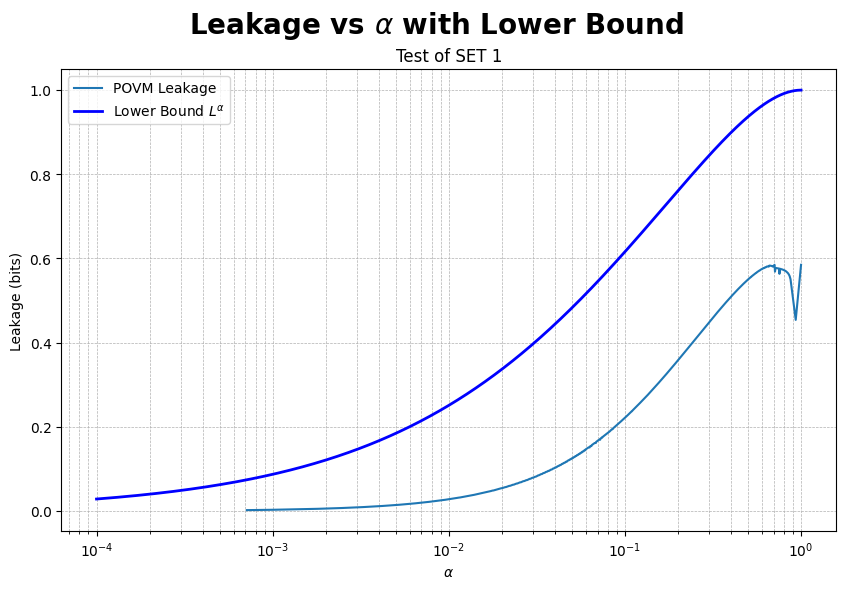

In [19]:
plt.figure(figsize=(10, 6))
plt.plot(alpha_upper, leakage_upper,  markersize=2, label='POVM Leakage')
plt.plot(alpha_values_lb, L_alpha_values, color='blue', linewidth=2, label='Lower Bound $L^{\\alpha}$')
plt.xscale('log')
plt.xlabel(r'$\alpha$')
plt.ylabel('Leakage (bits)')
plt.title(r'Test of SET 1', fontsize=12)
plt.suptitle(r'Leakage vs $\alpha$ with Lower Bound', fontsize=20, fontweight='bold')  # Bigger main title

plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.show()

#### Depolarizing-channel comparison

The same parameter sweep is repeated after applying depolarizing noise with $p=0.2$ and $p=0.4$. This isolates the effect of channel noise on the leakage--disturbance curve while keeping the measurement family unchanged.


In [20]:
p = 0.2  # Noise parameter

# NO IDEAL CHANNEL ANYMORE
possible_states_noisy = [
    depolarising_channel(rho, p)
    for rho in POSSIBLE_STATES
]

In [21]:
# To store the upper curve
upper_envelope_n1 = {}


# Create linspace arrays for epsilon and theta
epsilon_values = np.linspace(0, 1, 250)
theta_values = np.linspace(0, np.pi/4, 250)

alpha_leakage_list_set_1 = []
# Scan all sampled (epsilon, theta) combinations
for epsilon in epsilon_values:
    for theta in theta_values:
        
        # Generate Kraus operators for the current parameters
        b0, b1 = generate_krauss_operators_set_1(epsilon, theta)
        krauss_operators = [b0, b1]
        
        # Calculate alpha and leakage
        alpha = calculate_alpha(krauss_operators, possible_states_noisy)
        leakage = calculate_mutual_info_sibson(krauss_operators, possible_states_noisy)
        
        # Store results
        alpha_leakage_list_set_1.append((alpha, leakage))
        
        bin_idx = alpha_to_bin(alpha, alpha_bin_edges)
        if bin_idx is None:
            continue

        # Keep only the maximum leakage per alpha-bin
        if bin_idx not in upper_envelope_n1:
            upper_envelope_n1[bin_idx] = {
                "alpha": alpha,
                "leakage": leakage,
                "params": (epsilon, theta),
            }
        else:
            if leakage > upper_envelope_n1[bin_idx]["leakage"]:
                upper_envelope_n1[bin_idx] = {
                    "alpha": alpha,
                    "leakage": leakage,
                    "params": (epsilon, theta),
                }


C:\Users\pablo\AppData\Local\Temp\ipykernel_10340\3768467288.py:13: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  b1 = sqrtm(povm_1)


In [22]:
# Sort alpha_leakage_list by alpha (first element of each tuple)
alpha_leakage_list_set_1_sorted = sorted(alpha_leakage_list_set_1, key=lambda x: x[0])

# Extract alpha and leakage values
alphas_set_1 = [item[0] for item in alpha_leakage_list_set_1_sorted]
leakages_set_1 = [item[1] for item in alpha_leakage_list_set_1_sorted]

In [23]:
alpha_upper_n1 = []
leakage_upper_n1 = []

for idx in sorted(upper_envelope_n1.keys()):
    alpha_upper_n1.append(upper_envelope_n1[idx]["alpha"])
    leakage_upper_n1.append(upper_envelope_n1[idx]["leakage"])


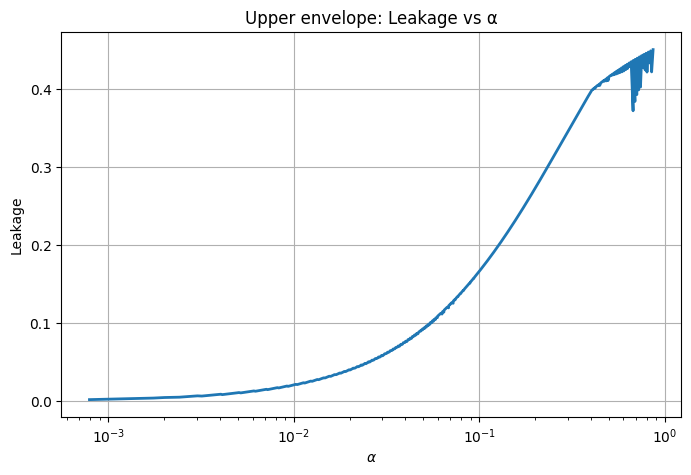

In [24]:
plt.figure(figsize=(8,5))
plt.plot(alpha_upper_n1, leakage_upper_n1, linewidth=2)
plt.xscale("log")
plt.xlabel(r"$\alpha$")
plt.ylabel("Leakage")
plt.title("Upper envelope: Leakage vs α")
plt.grid(True)
plt.show()


In [25]:
p = 0.4  # Noise parameter

# NO IDEAL CHANNEL ANYMORE
possible_states_noisy_2 = [
    depolarising_channel(rho, p)
    for rho in POSSIBLE_STATES
]

In [26]:
# To store the upper curve
upper_envelope_n2 = {}


# Create linspace arrays for epsilon and theta
epsilon_values = np.linspace(0, 1, 250)
theta_values = np.linspace(0, np.pi/4, 250)

alpha_leakage_list_set_2 = []
# Scan all sampled (epsilon, theta) combinations
for epsilon in epsilon_values:
    for theta in theta_values:
        
        # Generate Kraus operators for the current parameters
        b0, b1 = generate_krauss_operators_set_1(epsilon, theta)
        krauss_operators = [b0, b1]
        
        # Calculate alpha and leakage
        alpha = calculate_alpha(krauss_operators, possible_states_noisy_2)
        leakage = calculate_mutual_info_sibson(krauss_operators, possible_states_noisy_2)
        
        # Store results
        alpha_leakage_list_set_1.append((alpha, leakage))
        
        bin_idx = alpha_to_bin(alpha, alpha_bin_edges)
        if bin_idx is None:
            continue

        # Keep only the maximum leakage per alpha-bin
        if bin_idx not in upper_envelope_n2:
            upper_envelope_n2[bin_idx] = {
                "alpha": alpha,
                "leakage": leakage,
                "params": (epsilon, theta),
            }
        else:
            if leakage > upper_envelope_n2[bin_idx]["leakage"]:
                upper_envelope_n2[bin_idx] = {
                    "alpha": alpha,
                    "leakage": leakage,
                    "params": (epsilon, theta),
                }


C:\Users\pablo\AppData\Local\Temp\ipykernel_10340\3768467288.py:13: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  b1 = sqrtm(povm_1)


In [27]:
# Sort alpha_leakage_list by alpha (first element of each tuple)
alpha_leakage_list_set_2_sorted = sorted(alpha_leakage_list_set_2, key=lambda x: x[0])

# Extract alpha and leakage values
alphas_set_2 = [item[0] for item in alpha_leakage_list_set_2_sorted]
leakages_set_2 = [item[1] for item in alpha_leakage_list_set_2_sorted]

In [28]:
alpha_upper_n2 = []
leakage_upper_n2 = []

for idx in sorted(upper_envelope_n2.keys()):
    alpha_upper_n2.append(upper_envelope_n2[idx]["alpha"])
    leakage_upper_n2.append(upper_envelope_n2[idx]["leakage"])


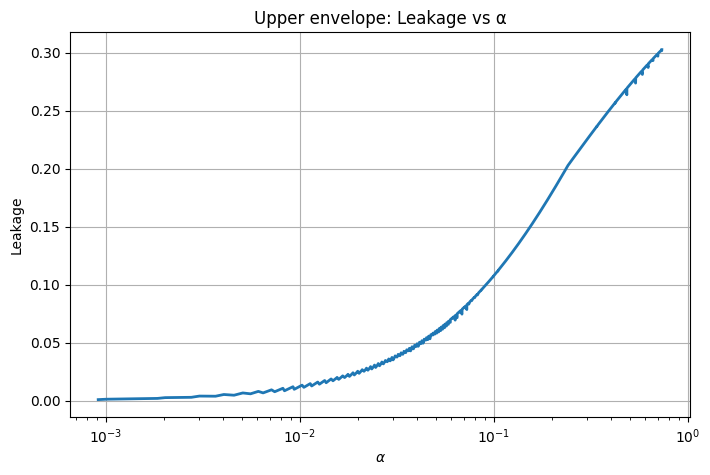

In [29]:
plt.figure(figsize=(8,5))
plt.plot(alpha_upper_n2, leakage_upper_n2, linewidth=2)
plt.xscale("log")
plt.xlabel(r"$\alpha$")
plt.ylabel("Leakage")
plt.title("Upper envelope: Leakage vs α")
plt.grid(True)
plt.show()


The next cell reports the largest leakage encountered in the noiseless grid together with the parameter values that produced it. This is a **grid maximum for this family**, not a global optimum over all POVMs.


In [30]:
best_entry = max(upper_envelope.values(), key=lambda x: x["leakage"])

print(f"Highest Leakage: {best_entry['leakage']}")
print(f"Resulting Alpha: {best_entry['alpha']}")
print(f"Used Epsilon_0: {best_entry['params'][0]}")
print(f"Used Epsilon_1: {best_entry['params'][1]}")

Highest Leakage: 0.5849625007211566
Resulting Alpha: 0.7071067811865476
Used Epsilon_0: 1.0
Used Epsilon_1: 0.7853981633974483


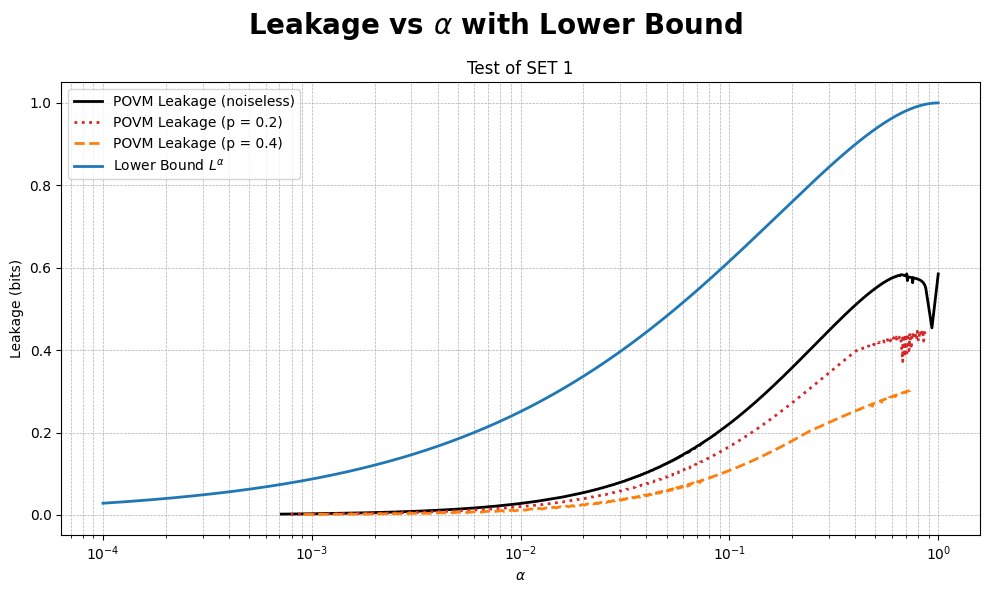

In [31]:
plt.figure(figsize=(10, 6))

# Noiseless POVM leakage
plt.plot(
    alpha_upper,
    leakage_upper,
    color='black',
    linewidth=2,
    label='POVM Leakage (noiseless)'
)

# Depolarising noise p = 0.2
plt.plot(
    alpha_upper_n1,
    leakage_upper_n1,
    color='tab:red',
    linestyle=':',
    linewidth=2,
    label='POVM Leakage (p = 0.2)'
)



# Depolarising noise p = 0.4
plt.plot(
    alpha_upper_n2,
    leakage_upper_n2,
    color='tab:orange',
    linestyle='--',
    linewidth=2,
    label='POVM Leakage (p = 0.4)'
)

# Lower bound
plt.plot(
    alpha_values_lb,
    L_alpha_values,
    color='tab:blue',
    linewidth=2,
    label=r'Lower Bound $L^{\alpha}$'
)

plt.xscale('log')
plt.xlabel(r'$\alpha$')
plt.ylabel('Leakage (bits)')

plt.title(r'Test of SET 1', fontsize=12)
plt.suptitle(
    r'Leakage vs $\alpha$ with Lower Bound',
    fontsize=20,
    fontweight='bold'
)

plt.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.legend(
    loc='best',
    fontsize=10,
    frameon=True
)

plt.tight_layout()
plt.show()


### 5.2 POVM family 2: two-direction perturbation


The second binary family introduces two independent perturbation directions, one associated with $|0\rangle$ and another with $|+\rangle$:

$$
F_0
=
\frac{1}{2}
\left(
I+\epsilon_0|0\rangle\langle0|
+\epsilon_1|+\rangle\langle+|
\right),
$$

$$
F_1
=
\frac{1}{2}
\left(
I-\epsilon_0|0\rangle\langle0|
-\epsilon_1|+\rangle\langle+|
\right),
$$

with $\epsilon_0,\epsilon_1\in[0,1]$ in the original exploratory scan.

> **Validity note.** The square parameter box does not automatically guarantee that both effects are positive semidefinite. The original scan below was exploratory and does not explicitly filter every parameter pair by the POVM positivity constraints. Consequently, points generated outside the physical region should not be interpreted as valid POVM attacks. This limitation is one reason the final thesis analysis moved to an explicitly constrained cloning region.


In [32]:
def generate_krauss_operators_set_2(epsilon_0, epsilon_1):
    """Given parameters epsilon and theta generates a set of POVMs
    and returns its krauss operators"""
    
    Id = np.array([[1,0],[0,1]])
    appendix_0 = np.array([[1,0],[0,0]])
    appendix_1 = 0.5 * np.array([[1,1],[1,1]])
    
    
    povm_0 = 0.5 * (Id + epsilon_0 * appendix_0 + epsilon_1 * appendix_1)
    povm_1 = 0.5 * (Id - epsilon_0 * appendix_0 - epsilon_1 * appendix_1)
    
    b0 = sqrtm(povm_0)
    b1 = sqrtm(povm_1)
    
    return b0,b1
    


For a parameter point inside the physical region, completeness is checked through

$$
B_0^\dagger B_0+B_1^\dagger B_1=I.
$$

A deterministic valid test point is used here so that the implementation check is reproducible.


In [33]:
# Use a deterministic parameter point inside the physical region.
epsilon_0 = 0.2
epsilon_1 = 0.2

b0, b1 = generate_krauss_operators_set_2(epsilon_0, epsilon_1)

print(f"{b0 = }")
print(f"{b1 = }")

Id_check = b0.conj().T @ b0 + b1.conj().T @ b1

print(f"Completeness check B0†B0 + B1†B1:\n{Id_check}")
print(f"Matches identity: {np.allclose(Id_check, np.eye(2), atol=1e-10)}")


b0 = array([[0.80557724, 0.03233124],
       [0.03233124, 0.74091477]])
b1 = array([[ 0.59027544, -0.03968503],
       [-0.03968503,  0.6696455 ]])
Completeness check B0†B0 + B1†B1:
[[1.00000000e+00 4.16333634e-17]
 [4.16333634e-17 1.00000000e+00]]
Matches identity: True


In [34]:
# To store the upper curve
upper_envelope_2 = {}




# Create linspace arrays for epsilon_0 and epsilon_1
epsilon_0_values = np.linspace(0, 1, 250)
epsilon_1_values = np.linspace(0, 1, 250)
# Grid resolution chosen to keep the exploratory sweep tractable

alpha_leakage_list_set_2 = []
# Scan all sampled (epsilon_0, epsilon_1) combinations
for epsilon_0 in epsilon_0_values:
    for epsilon_1 in epsilon_1_values:
        # Generate Kraus operators for the current parameters
        b0, b1 = generate_krauss_operators_set_2(epsilon_0, epsilon_1)
        krauss_operators = [b0, b1]
        
        # Calculate alpha and leakage
        alpha = calculate_alpha(krauss_operators, POSSIBLE_STATES)
        leakage = calculate_mutual_info_sibson(krauss_operators, POSSIBLE_STATES)
        
        # Store results
        alpha_leakage_list_set_2.append((alpha, leakage))
        
        bin_idx = alpha_to_bin(alpha, alpha_bin_edges)
        if bin_idx is None:
            continue

        # Keep only the maximum leakage per alpha-bin
        if bin_idx not in upper_envelope_2:
            upper_envelope_2[bin_idx] = {
                "alpha": alpha,
                "leakage": leakage,
                "params": (epsilon_0, epsilon_1),
            }
        else:
            if leakage > upper_envelope_2[bin_idx]["leakage"]:
                upper_envelope_2[bin_idx] = {
                    "alpha": alpha,
                    "leakage": leakage,
                    "params": (epsilon_0, epsilon_1),
                }


C:\Users\pablo\AppData\Local\Temp\ipykernel_10340\4218290150.py:14: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  b1 = sqrtm(povm_1)


In [35]:
alpha_leakage_list_set_2_sorted = sorted(alpha_leakage_list_set_2, key=lambda x: x[0])

# Extract alpha and leakage values
alphas_set_2 = [item[0] for item in alpha_leakage_list_set_2_sorted]
leakages_set_2 = [item[1] for item in alpha_leakage_list_set_2_sorted]


The sampled disturbance--leakage points are again displayed on a logarithmic $\alpha$ axis.


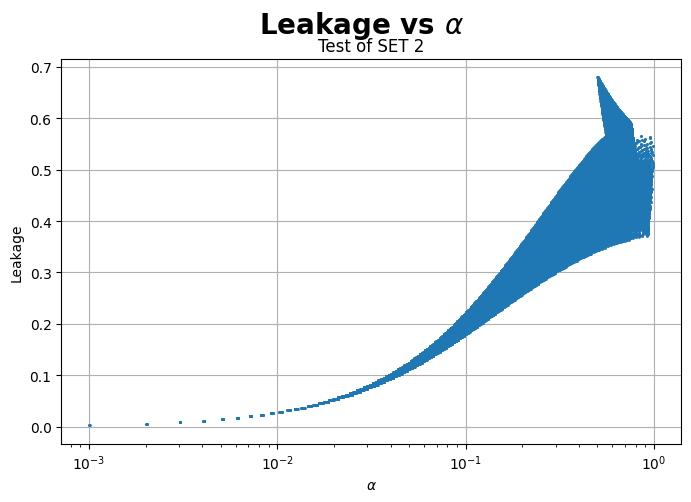

In [36]:
# Plot with logarithmic x-axis
plt.figure(figsize=(8, 5))
plt.plot(alphas_set_2, leakages_set_2, marker='.', linestyle='None', markersize=2)
plt.xlabel(r'$\alpha$')
plt.ylabel('Leakage')
plt.title(r'Test of SET 2', fontsize=12)
plt.suptitle(r'Leakage vs $\alpha$', fontsize=20, fontweight='bold')  # Bigger main title
plt.xscale('log')  # Set x-axis to logarithmic scale
plt.grid(True)
plt.show()

As before, the upper envelope keeps the largest leakage found in each $\alpha$ bin.


In [37]:
alpha_upper_2 = []
leakage_upper_2 = []

for idx in sorted(upper_envelope_2.keys()):
    alpha_upper_2.append(upper_envelope_2[idx]["alpha"])
    leakage_upper_2.append(upper_envelope_2[idx]["leakage"])


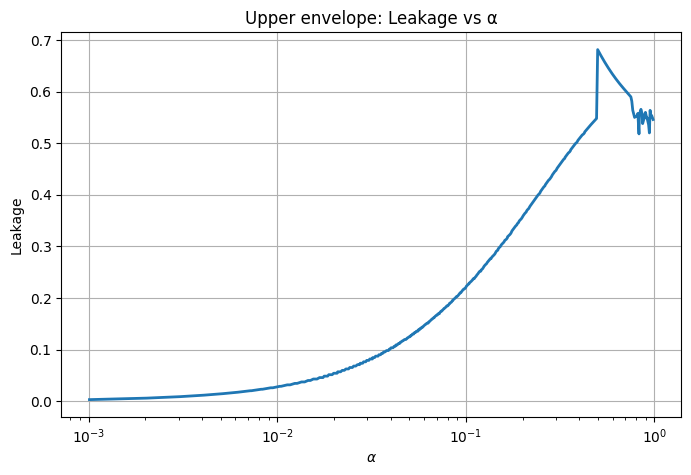

In [38]:
plt.figure(figsize=(8,5))
plt.plot(alpha_upper_2, leakage_upper_2, linewidth=2)
plt.xscale("log")
plt.xlabel(r"$\alpha$")
plt.ylabel("Leakage")
plt.title("Upper envelope: Leakage vs α")
plt.grid(True)
plt.show()


The following diagnostic reports the largest value encountered by the **raw parameter scan**. Because the original sweep does not enforce positivity over the entire $(\epsilon_0,\epsilon_1)$ square, this value should be treated as exploratory rather than as a physically certified optimum.


In [39]:
best_entry = max(upper_envelope_2.values(), key=lambda x: x["leakage"])

print(f"Highest Leakage: {best_entry['leakage']}")
print(f"Resulting Alpha: {best_entry['alpha']}")
print(f"Used Epsilon_0: {best_entry['params'][0]}")
print(f"Used Epsilon_1: {best_entry['params'][1]}")

Highest Leakage: 0.6812723893653587
Resulting Alpha: 0.49999999999999994
Used Epsilon_0: 1.0
Used Epsilon_1: 1.0


The empirical envelope is then compared with the same analytical lower bound used for the first family.


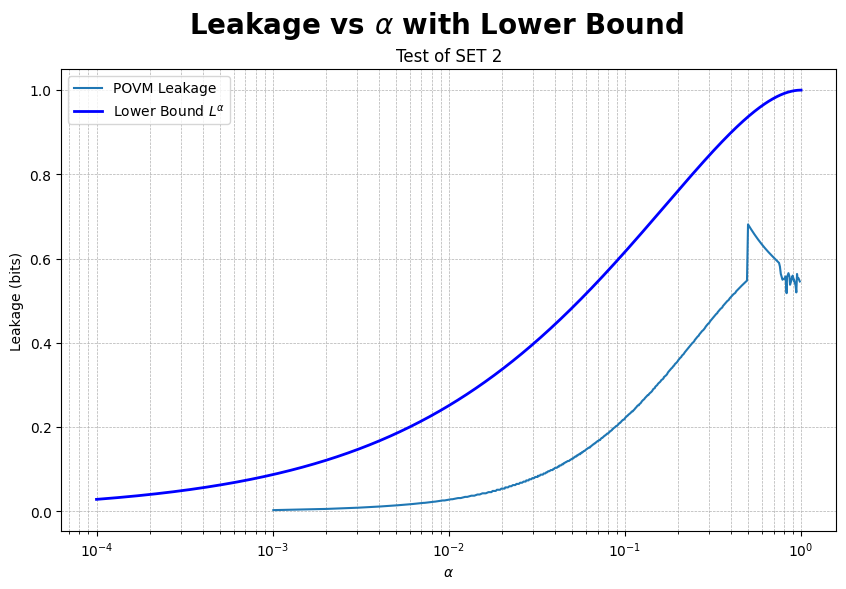

In [40]:
plt.figure(figsize=(10, 6))
plt.plot(alpha_upper_2, leakage_upper_2, markersize=2, label='POVM Leakage')
plt.plot(alpha_values_lb, L_alpha_values, color='blue', linewidth=2, label='Lower Bound $L^{\\alpha}$')
plt.xscale('log')
plt.xlabel(r'$\alpha$')
plt.ylabel('Leakage (bits)')
plt.title(r'Test of SET 2', fontsize=12)
plt.suptitle(r'Leakage vs $\alpha$ with Lower Bound', fontsize=20, fontweight='bold')  # Bigger main title


plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.show()

#### Depolarizing-channel comparison

The family-2 scan is repeated for $p=0.2$ and $p=0.4$ to inspect how depolarization changes the sampled leakage--disturbance behavior.


In [41]:
p = 0.2  # Noise parameter

# NO IDEAL CHANNEL ANYMORE
possible_states_noisy_1 = [
    depolarising_channel(rho, p)
    for rho in POSSIBLE_STATES
]

In [42]:
# To store the upper curve
upper_envelope_2_n1 = {}




# Create linspace arrays for epsilon_0 and epsilon_1
epsilon_0_values = np.linspace(0, 1, 250)
epsilon_1_values = np.linspace(0, 1, 250)
# Grid resolution chosen to keep the exploratory sweep tractable

alpha_leakage_list_set_2_n1 = []
# Scan all sampled (epsilon_0, epsilon_1) combinations
for epsilon_0 in epsilon_0_values:
    for epsilon_1 in epsilon_1_values:
        # Generate Kraus operators for the current parameters
        b0, b1 = generate_krauss_operators_set_2(epsilon_0, epsilon_1)
        krauss_operators = [b0, b1]
        
        # Calculate alpha and leakage
        alpha = calculate_alpha(krauss_operators, possible_states_noisy_1)
        leakage = calculate_mutual_info_sibson(krauss_operators, possible_states_noisy_1)
        
        # Store results
        alpha_leakage_list_set_2.append((alpha, leakage))
        
        bin_idx = alpha_to_bin(alpha, alpha_bin_edges)
        if bin_idx is None:
            continue

        # Keep only the maximum leakage per alpha-bin
        if bin_idx not in upper_envelope_2_n1:
            upper_envelope_2_n1[bin_idx] = {
                "alpha": alpha,
                "leakage": leakage,
                "params": (epsilon_0, epsilon_1),
            }
        else:
            if leakage > upper_envelope_2_n1[bin_idx]["leakage"]:
                upper_envelope_2_n1[bin_idx] = {
                    "alpha": alpha,
                    "leakage": leakage,
                    "params": (epsilon_0, epsilon_1),
                }


C:\Users\pablo\AppData\Local\Temp\ipykernel_10340\4218290150.py:14: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  b1 = sqrtm(povm_1)


In [43]:
alpha_leakage_list_set_2_n1_sorted = sorted(alpha_leakage_list_set_2_n1, key=lambda x: x[0])

# Extract alpha and leakage values
alphas_set_2_n1 = [item[0] for item in alpha_leakage_list_set_2_n1_sorted]
leakages_set_2_n1 = [item[1] for item in alpha_leakage_list_set_2_n1_sorted]


In [44]:
alpha_upper_2_n1 = []
leakage_upper_2_n1 = []

for idx in sorted(upper_envelope_2_n1.keys()):
    alpha_upper_2_n1.append(upper_envelope_2_n1[idx]["alpha"])
    leakage_upper_2_n1.append(upper_envelope_2_n1[idx]["leakage"])


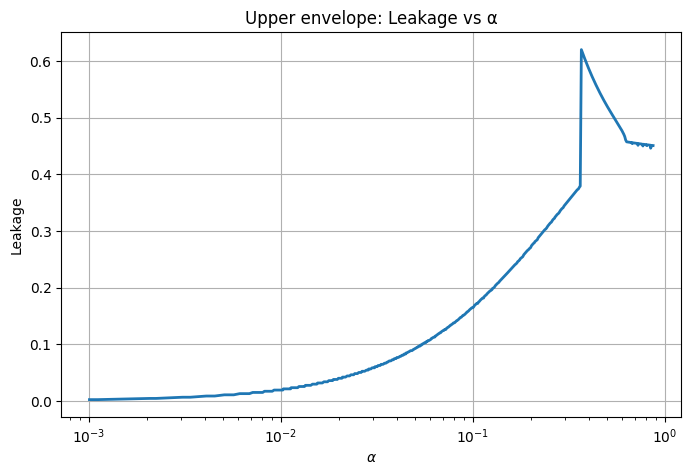

In [45]:
plt.figure(figsize=(8,5))
plt.plot(alpha_upper_2_n1, leakage_upper_2_n1, linewidth=2)
plt.xscale("log")
plt.xlabel(r"$\alpha$")
plt.ylabel("Leakage")
plt.title("Upper envelope: Leakage vs α")
plt.grid(True)
plt.show()


In [46]:
p = 0.4  # Noise parameter

# NO IDEAL CHANNEL ANYMORE
possible_states_noisy_2 = [
    depolarising_channel(rho, p)
    for rho in POSSIBLE_STATES
]

In [47]:
# To store the upper curve
upper_envelope_2_n2 = {}




# Create linspace arrays for epsilon_0 and epsilon_1
epsilon_0_values = np.linspace(0, 1, 250)
epsilon_1_values = np.linspace(0, 1, 250)
# Grid resolution chosen to keep the exploratory sweep tractable

alpha_leakage_list_set_2_n2 = []
# Scan all sampled (epsilon_0, epsilon_1) combinations
for epsilon_0 in epsilon_0_values:
    for epsilon_1 in epsilon_1_values:
        # Generate Kraus operators for the current parameters
        b0, b1 = generate_krauss_operators_set_2(epsilon_0, epsilon_1)
        krauss_operators = [b0, b1]
        
        # Calculate alpha and leakage
        alpha = calculate_alpha(krauss_operators, possible_states_noisy_2)
        leakage = calculate_mutual_info_sibson(krauss_operators, possible_states_noisy_2)
        
        # Store results
        alpha_leakage_list_set_2.append((alpha, leakage))
        
        bin_idx = alpha_to_bin(alpha, alpha_bin_edges)
        if bin_idx is None:
            continue

        # Keep only the maximum leakage per alpha-bin
        if bin_idx not in upper_envelope_2_n2:
            upper_envelope_2_n2[bin_idx] = {
                "alpha": alpha,
                "leakage": leakage,
                "params": (epsilon_0, epsilon_1),
            }
        else:
            if leakage > upper_envelope_2_n2[bin_idx]["leakage"]:
                upper_envelope_2_n2[bin_idx] = {
                    "alpha": alpha,
                    "leakage": leakage,
                    "params": (epsilon_0, epsilon_1),
                }


C:\Users\pablo\AppData\Local\Temp\ipykernel_10340\4218290150.py:14: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  b1 = sqrtm(povm_1)


In [48]:
alpha_leakage_list_set_2_n2_sorted = sorted(alpha_leakage_list_set_2_n2, key=lambda x: x[0])

# Extract alpha and leakage values
alphas_set_2_n2 = [item[0] for item in alpha_leakage_list_set_2_n2_sorted]
leakages_set_2_n2 = [item[1] for item in alpha_leakage_list_set_2_n2_sorted]


In [49]:
alpha_upper_2_n2 = []
leakage_upper_2_n2 = []

for idx in sorted(upper_envelope_2_n2.keys()):
    alpha_upper_2_n2.append(upper_envelope_2_n2[idx]["alpha"])
    leakage_upper_2_n2.append(upper_envelope_2_n2[idx]["leakage"])


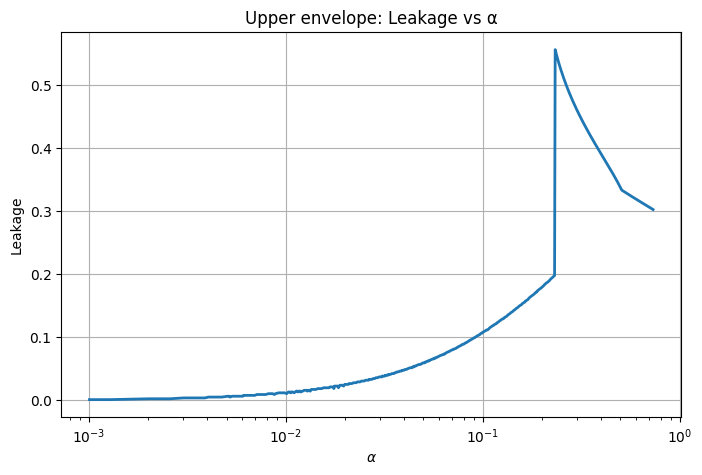

In [50]:
plt.figure(figsize=(8,5))
plt.plot(alpha_upper_2_n2, leakage_upper_2_n2, linewidth=2)
plt.xscale("log")
plt.xlabel(r"$\alpha$")
plt.ylabel("Leakage")
plt.title("Upper envelope: Leakage vs α")
plt.grid(True)
plt.show()


#### Family-2 comparison across channel conditions

The following plot overlays the noiseless and noisy envelopes together with the analytical reference bound.


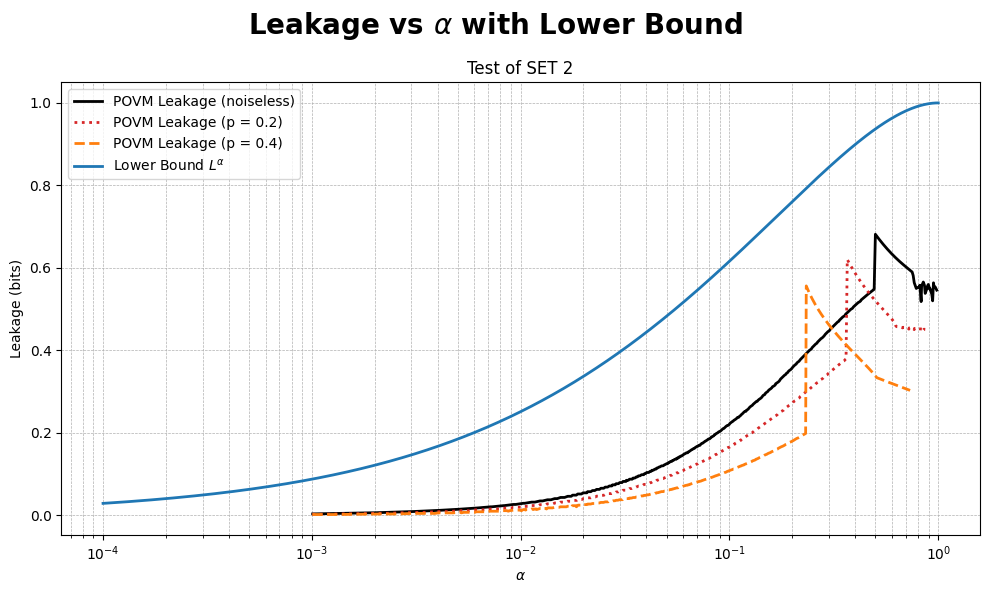

In [51]:
plt.figure(figsize=(10, 6))

# Noiseless POVM leakage
plt.plot(
    alpha_upper_2,
    leakage_upper_2,
    color='black',
    linewidth=2,
    label='POVM Leakage (noiseless)'
)

# Depolarising noise p = 0.2
plt.plot(
    alpha_upper_2_n1,
    leakage_upper_2_n1,
    color='tab:red',
    linestyle=':',
    linewidth=2,
    label='POVM Leakage (p = 0.2)'
)



# Depolarising noise p = 0.4
plt.plot(
    alpha_upper_2_n2,
    leakage_upper_2_n2,
    color='tab:orange',
    linestyle='--',
    linewidth=2,
    label='POVM Leakage (p = 0.4)'
)

# Lower bound
plt.plot(
    alpha_values_lb,
    L_alpha_values,
    color='tab:blue',
    linewidth=2,
    label=r'Lower Bound $L^{\alpha}$'
)

plt.xscale('log')
plt.xlabel(r'$\alpha$')
plt.ylabel('Leakage (bits)')

plt.title(r'Test of SET 2', fontsize=12)
plt.suptitle(
    r'Leakage vs $\alpha$ with Lower Bound',
    fontsize=20,
    fontweight='bold'
)

plt.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.legend(
    loc='best',
    fontsize=10,
    frameon=True
)

plt.tight_layout()
plt.show()


### 5.3 POVM family 3: state-pair construction


The third construction follows the measurement strategy introduced in *Measuring Quantum Information Leakage Under Detection Threat*. Instead of choosing an arbitrary perturbation direction, the measurement is built from the difference between two candidate signal states.


Given two candidate states $\rho_x$ and $\rho_{x'}$, define

$$
\Delta=\rho_x-\rho_{x'}.
$$

Since $\Delta$ is Hermitian, write its Jordan decomposition as

$$
\Delta=L_+-L_-,
\qquad
L_+\succeq0,\quad L_-\succeq0.
$$

Using $L_+$, the three Kraus operators are parameterized by $\varepsilon$ as

$$
B_+
=
\sqrt{\frac{1-2\varepsilon^2}{2}}\,I+\varepsilon L_+,
$$

$$
B_-
=
\sqrt{\frac{1-2\varepsilon^2}{2}}\,I-\varepsilon L_+,
$$

$$
B_0
=
\sqrt{2}\,\varepsilon\left(I-L_+^2\right)^{1/2}.
$$

The corresponding POVM elements are $F_y=B_y^\dagger B_y$ for $y\in\{+,-,0\}$. The $B_0$ term completes the measurement so that the effects sum to the identity. The allowed sweep is restricted to $\varepsilon<1/\sqrt{2}$ so that the prefactor in $B_\pm$ remains real.


In [52]:
def construct_kraus_operators(rho1, rho2, epsilon):
    """
    Construct the POVM and Measurement Operators for a gentle measurement
    based on two density matrices rho1, rho2.

    Returns
    -------
    povm : list of np.ndarray
        The list [F_+, F_-, F_0] where F_y = B_y^dag @ B_y.
    kraus_operators : list of np.ndarray
        The list [B_+, B_-, B_0].
    """

    d = rho1.shape[0]
    I = np.eye(d)

    # Spectral decomposition of Hermitian difference
    Delta = rho1 - rho2
    eigvals, eigvecs = np.linalg.eigh((Delta + Delta.conj().T)/2) # enforce Hermiticity numerically

    # Build L_+
    L_plus = np.zeros((d, d), dtype=complex)
    for lam, v in zip(eigvals, eigvecs.T):
        proj = np.outer(v, v.conj())
        if lam >= 0:
            L_plus += lam * proj
        
    # Construct B operators 
    pref = np.sqrt((1 - 2 * epsilon**2) / 2)
    B_plus  = pref * I + epsilon * L_plus
    B_minus = pref * I - epsilon * L_plus
    
    # Compute (I - L_+^2)^{1/2} for B_0
    M = I - L_plus @ L_plus.conj().T
    M_sqrt = sqrtm((M + M.conj().T)/2) # enforce Hermiticity numerically
    B_0 = np.sqrt(2) * epsilon * M_sqrt

    # 1. Group the Measurement Operators
    kraus_operators = [B_plus, B_minus, B_0]

    # 2. Construct the POVM elements
    # Relation: F_y = B_y^dagger @ B_y
    povm = []
    for B in kraus_operators:
        povm.append( B.conj().T @ B )

    return povm, kraus_operators

The construction requires a pair of candidate states. I test every pair from the BB84 ensemble

$$
S=\{|0\rangle,|1\rangle,|+\rangle,|-\rangle\},
$$

where

$$
|+\rangle=\frac{|0\rangle+|1\rangle}{\sqrt{2}},
\qquad
|-\rangle=\frac{|0\rangle-|1\rangle}{\sqrt{2}}.
$$

For each $\varepsilon$, all distinct state pairs are evaluated and the best leakage found in each $\alpha$ bin is retained.


The density-matrix representation of the BB84 ensemble is reused below for clarity.


In [53]:
POSSIBLE_STATES = [np.array([[1,0],[0,0]]),     # |0>
                np.array([[0,0],[0,1]]),        # |1>
                0.5*np.array([[1,1],[1,1]]),    # |+>
                0.5*np.array([[1,-1],[-1,1]])]  # |->

In [54]:
epsilon = 0.25
povm , kraus_operators = construct_kraus_operators(POSSIBLE_STATES[0], POSSIBLE_STATES[1], epsilon)

C:\Users\pablo\AppData\Local\Temp\ipykernel_10340\1317129797.py:35: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  M_sqrt = sqrtm((M + M.conj().T)/2) # enforce Hermiticity numerically


In [55]:
B_plus = kraus_operators[0]
B_minus = kraus_operators[1]
B0 = kraus_operators[2]

Id_check = (
    B_plus.conj().T @ B_plus
    + B_minus.conj().T @ B_minus
    + B0.conj().T @ B0
)

print(f"Completeness check B+†B+ + B-†B- + B0†B0:\n{Id_check}")
print(f"Matches identity: {np.allclose(Id_check, np.eye(2), atol=1e-10)}")


Completeness check B+†B+ + B-†B- + B0†B0:
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
Matches identity: True


I now sweep $\varepsilon$ over its allowed interval and repeat the construction for every distinct pair of BB84 states. This produces a larger candidate set than the previous two hand-designed binary families.


In [56]:
# To store the upper curve
upper_envelope_3 = {}

# Create linspace arrays for epsilon
epsilon_values = np.linspace(0, 1/np.sqrt(2)-0.001, 1000) # EPSILON MUST BE BETWEEN [0,1/sqrt(2))
# Dense epsilon grid for the one-dimensional parameter sweep

alpha_leakage_list_set_3 = []

# Sweep epsilon and all distinct BB84 state pairs
for epsilon in epsilon_values:
    
    for i in range( len(POSSIBLE_STATES) - 1):
        for j in range(i + 1,len(POSSIBLE_STATES) ):
    
            povm, kraus_operators = construct_kraus_operators(POSSIBLE_STATES[i], POSSIBLE_STATES[j], epsilon)
        
            # Calculate alpha and leakage
            alpha = calculate_alpha(kraus_operators, POSSIBLE_STATES)
            leakage = calculate_mutual_info_sibson(kraus_operators, POSSIBLE_STATES)
    
            # Store results
            alpha_leakage_list_set_3.append((alpha, leakage))
    
            bin_idx = alpha_to_bin(alpha, alpha_bin_edges)
            if bin_idx is None:
                continue

            # Keep only the maximum leakage per alpha-bin
            if bin_idx not in upper_envelope_3:
                upper_envelope_3[bin_idx] = {
                    "alpha": alpha,
                    "leakage": leakage,
                    "params": (epsilon, i, j),

                }
            else:
                if leakage > upper_envelope_3[bin_idx]["leakage"]:
                    upper_envelope_3[bin_idx] = {
                        "alpha": alpha,
                        "leakage": leakage,
                        "params": (epsilon, i, j),

                        }


C:\Users\pablo\AppData\Local\Temp\ipykernel_10340\1317129797.py:35: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  M_sqrt = sqrtm((M + M.conj().T)/2) # enforce Hermiticity numerically


In [57]:
#print(alpha_leakage_list_set_3)
#print(len(alpha_leakage_list_set_3))

In [58]:
# Sort alpha_leakage_list by alpha (first element of each tuple)
alpha_leakage_list_set_3_sorted = sorted(alpha_leakage_list_set_3, key=lambda x: x[0])

# Extract alpha and leakage values
alphas_set_3 = [item[0] for item in alpha_leakage_list_set_3_sorted]
leakages_set_3 = [item[1] for item in alpha_leakage_list_set_3_sorted]

The sampled points are again displayed on a logarithmic disturbance axis.


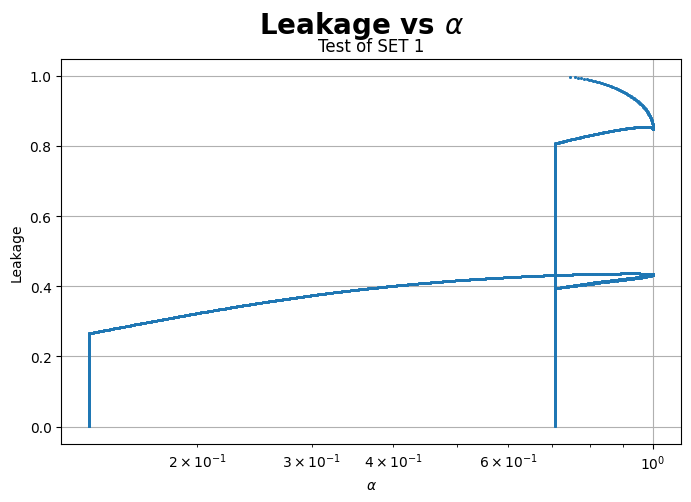

In [59]:
# Plot with logarithmic x-axis
plt.figure(figsize=(8, 5))
plt.plot(alphas_set_3, leakages_set_3, marker='.', linestyle='None', markersize=2)
plt.xlabel(r'$\alpha$')
plt.ylabel('Leakage')
plt.title(r'Test of SET 1', fontsize=12)
plt.suptitle(r'Leakage vs $\alpha$', fontsize=20, fontweight='bold')  # Bigger main title
plt.xscale('log')  # Set x-axis to logarithmic scale
plt.grid(True)
plt.show()

In [60]:
alpha_upper_3 = []
leakage_upper_3 = []

for idx in sorted(upper_envelope_3.keys()):
    alpha_upper_3.append(upper_envelope_3[idx]["alpha"])
    leakage_upper_3.append(upper_envelope_3[idx]["leakage"])


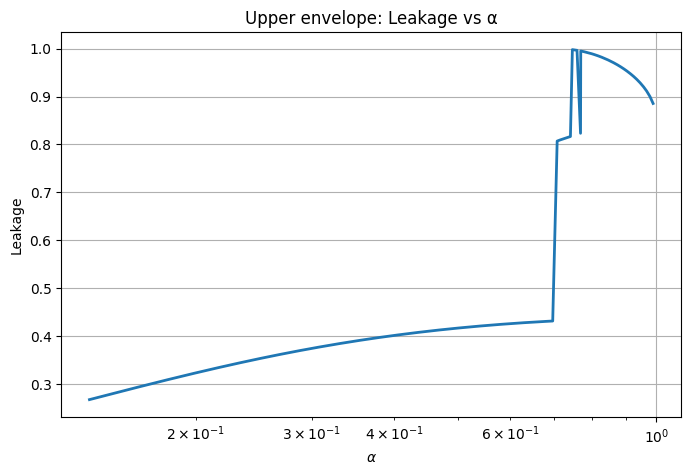

In [61]:
plt.figure(figsize=(8,5))
plt.plot(alpha_upper_3, leakage_upper_3, linewidth=2)
plt.xscale("log")
plt.xlabel(r"$\alpha$")
plt.ylabel("Leakage")
plt.title("Upper envelope: Leakage vs α")
plt.grid(True)
plt.show()


The next cell identifies the largest leakage reached in the sampled state-pair construction and records the corresponding $\varepsilon$ and BB84 state indices.


In [62]:
best_entry = max(upper_envelope_3.values(), key=lambda x: x["leakage"])

print(f"Highest Leakage: {best_entry['leakage']}")
print(f"Resulting Alpha: {best_entry['alpha']}")
print(f"Used Epsilon: {best_entry['params']}")

Highest Leakage: 0.9979597217876209
Resulting Alpha: 0.7456916343394602
Used Epsilon: (np.float64(0.7061067811865475), 0, 1)


Finally, the state-pair envelope is compared with the analytical lower bound. This comparison is particularly useful because the construction is motivated directly by the leakage framework rather than by an ad hoc choice of measurement direction.


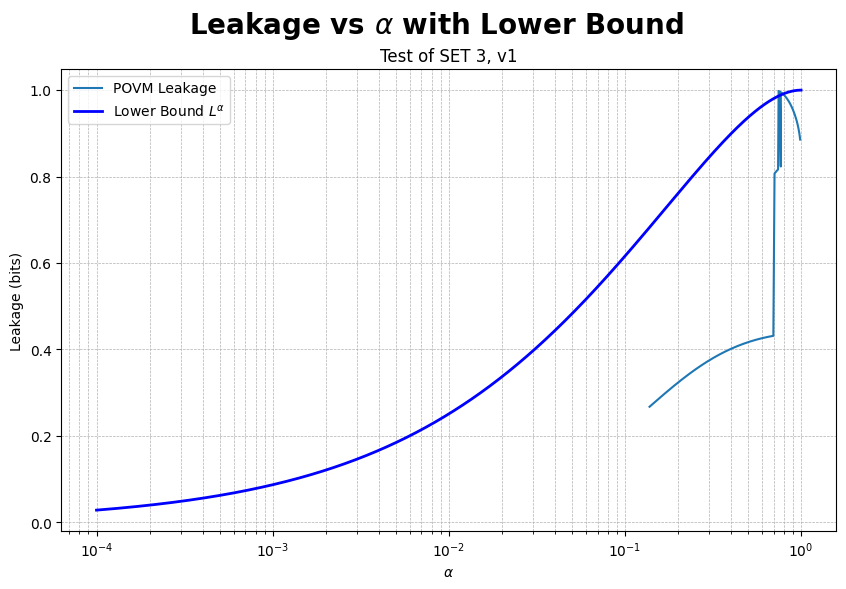

In [63]:
plt.figure(figsize=(10, 6))
plt.plot(alpha_upper_3, leakage_upper_3,  markersize=2, label='POVM Leakage')
plt.plot(alpha_values_lb, L_alpha_values, color='blue', linewidth=2, label='Lower Bound $L^{\\alpha}$')
plt.xscale('log')
plt.xlabel(r'$\alpha$')
plt.ylabel('Leakage (bits)')
plt.title(r'Test of SET 3, v1', fontsize=12)
plt.suptitle(r'Leakage vs $\alpha$ with Lower Bound', fontsize=20, fontweight='bold')  # Bigger main title

plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.show()

## 6. Implementation freedom of a fixed POVM

Weak gentleness depends on the existence of a favorable Kraus realization, so it is natural to ask whether the same POVM can be implemented in different ways that alter the disturbance.

A simple outcome-dependent global phase,

$$
K_x\longrightarrow K_x'=e^{i\phi_x}K_x,
$$

does **not** provide such freedom. It leaves the outcome probabilities, post-measurement state, and POVM effect unchanged:

$$
p'(x|\rho)
=
\operatorname{tr}(K_x'\rho K_x'^\dagger)
=
p(x|\rho),
$$

$$
\rho_x'
=
\frac{K_x'\rho K_x'^\dagger}{p'(x|\rho)}
=
\rho_x,
$$

$$
E_x'
=
K_x'^\dagger K_x'
=
E_x.
$$

Therefore a global phase cannot change either the leakage or the disturbance. Exploring genuinely different implementations would require a more general transformation than this phase degree of freedom.


### Optional extension: sampling the Bloch sphere

The primary analysis evaluates gentleness only on the four BB84 signal states, because those are the states relevant to the protocol considered in the thesis. The helper below generates a denser grid of pure qubit states on the Bloch sphere for possible robustness checks beyond the BB84 ensemble.

This extension is kept separate from the main results and is not used in the final comparison.


In [64]:
# ---------- 1) Generate "all possible states" (pure qubit grid) ----------
def pure_state_density(theta: float, phi: float) -> np.ndarray:
    """
    |psi> = cos(theta/2)|0> + exp(i phi) sin(theta/2)|1>
    rho = |psi><psi|
    """
    ket = np.array([
        np.cos(theta / 2.0),
        np.exp(1j * phi) * np.sin(theta / 2.0)
    ], dtype=complex)
    return np.outer(ket, ket.conj())

def bloch_sphere_grid(n_theta: int = 31, n_phi: int = 61) -> list[np.ndarray]:
    """
    Uniform grid in (theta, phi). Includes poles; phi duplicates at poles are harmless.
    Increase n_theta/n_phi for finer coverage.
    """
    thetas = np.linspace(0.0, np.pi, n_theta)
    phis   = np.linspace(0.0, 2.0*np.pi, n_phi, endpoint=False)
    states = []
    for th in thetas:
        for ph in phis:
            states.append(pure_state_density(th, ph))
    return states

POSSIBLE_STATES_ALL = bloch_sphere_grid(n_theta=31, n_phi=61)  # ~1891 states

## 7. Final comparison


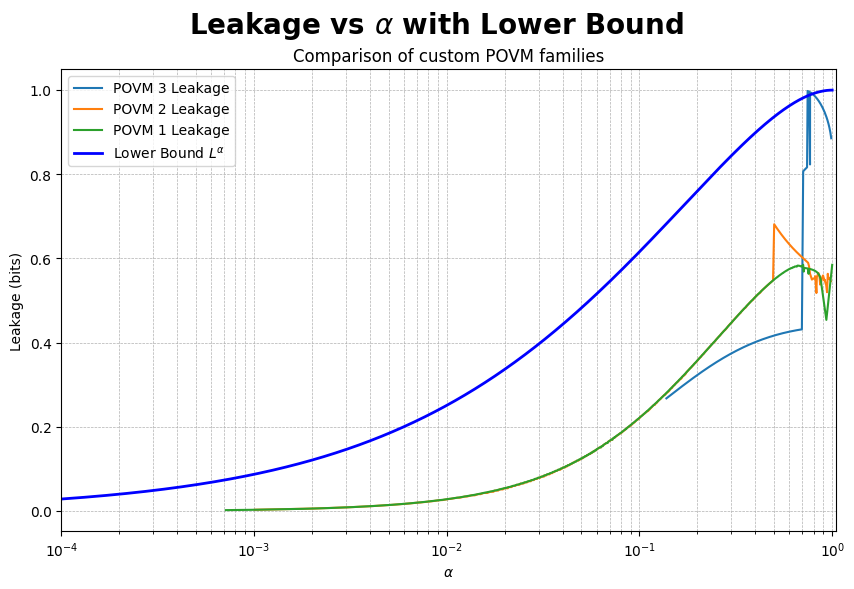

In [65]:
plt.figure(figsize=(10, 6))
plt.plot(alpha_upper_3, leakage_upper_3,  markersize=2, label='POVM 3 Leakage')
plt.plot(alpha_upper_2, leakage_upper_2,  markersize=2, label='POVM 2 Leakage')
plt.plot(alpha_upper, leakage_upper,  markersize=2, label='POVM 1 Leakage')
plt.plot(alpha_values_lb, L_alpha_values, color='blue', linewidth=2, label='Lower Bound $L^{\\alpha}$')
plt.xscale('log')
plt.xlim(0.0001, 1.05)
plt.xlabel(r'$\alpha$')
plt.ylabel('Leakage (bits)')
plt.title(r'Comparison of custom POVM families', fontsize=12)
plt.suptitle(r'Leakage vs $\alpha$ with Lower Bound', fontsize=20, fontweight='bold')


plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.show()


## Conclusion

This notebook explored whether a small number of explicit, parameterized POVM families could reproduce the information leakage permitted by the gentle-measurement framework while keeping the induced disturbance small.

Three constructions were investigated:

- a binary POVM based on a rotated rank-one perturbation;
- a two-direction binary perturbation, used as an exploratory extension;
- a three-outcome construction derived from the difference between pairs of BB84 signal states.

For each candidate implementation, I computed the worst-case trace-distance disturbance and the order-$\infty$ Sibson mutual information, then built an empirical leakage envelope as a function of $\alpha$. The first two families provide useful intuition about how the measurement strength and direction affect the leakage--disturbance trade-off. The third, state-pair construction reaches substantially larger leakage in the sampled regime and is more closely connected to the theoretical framework.

The study also exposes the main limitation of this approach: searching a few hand-designed POVM families does not characterize the full set of weakly gentle measurements, and additional physical constraints must be enforced explicitly when parameterizing arbitrary POVMs. Similarly, weak gentleness can depend on the Kraus realization, whereas this notebook evaluates only selected implementations.

These observations motivated the final stage of the thesis research, where the problem is reformulated through the **quantum cloning region**. That formulation provides a constrained and more systematic way to study the trade-off between information gained by an eavesdropper and disturbance introduced in the legitimate quantum channel.
